In [35]:
%cd /content/drive/MyDrive/Week_7_Tut_Lab_Activities


/content/drive/MyDrive/Week_7_Tut_Lab_Activities


In [36]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np
import os
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing import image

In [37]:
DATASET_DIR = '/content/drive/MyDrive/Week_7_Tut_Lab_Activities/Assets/Insects_dataset/Train_data'

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 123

In [38]:
print("Loading dataset with 80/20 train-validation split ... ")
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    DATASET_DIR,
    validation_split=0.2,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)
val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    DATASET_DIR,
    validation_split=0.2,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)
class_names = train_ds.class_names
num_classes = len(class_names)
print(f"Classes found: {class_names}")


Loading dataset with 80/20 train-validation split ... 
Found 433 files belonging to 3 classes.
Using 347 files for training.
Found 433 files belonging to 3 classes.
Using 86 files for validation.
Classes found: ['Asellus sp', 'Baetidae sp', 'Elmis sp']


In [39]:
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)


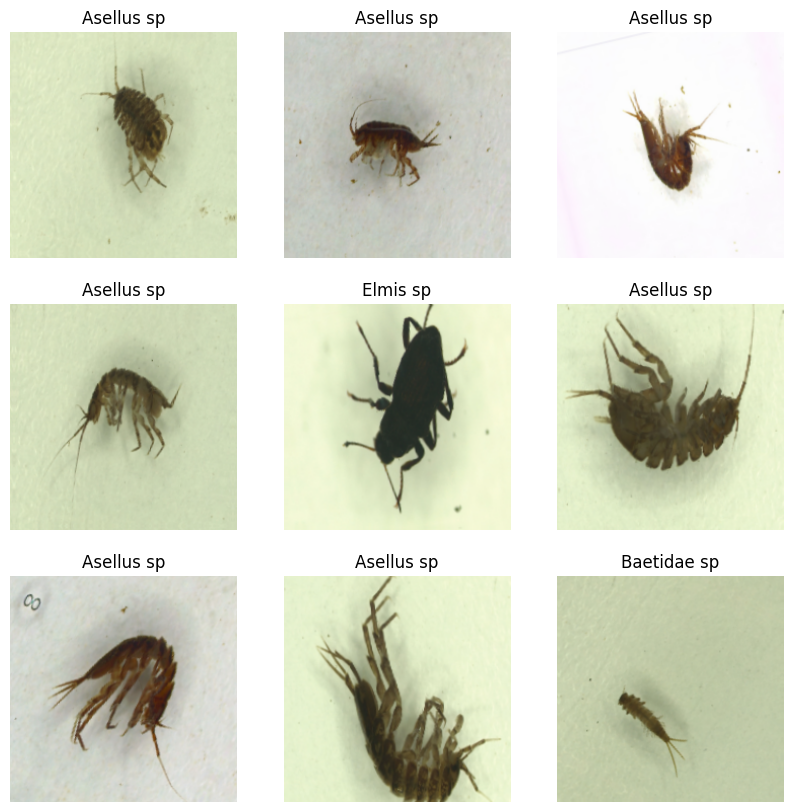

In [41]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
])
plt.figure(figsize=(10, 10))
for images, labels in train_ds.take(1):
    augmented_images = data_augmentation(images)
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(augmented_images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")
plt.show()


In [42]:
base_model = tf.keras.applications.MobileNetV2(
    input_shape=IMG_SIZE + (3,),
    include_top=False,
    weights='imagenet'
)

base_model.trainable = False

inputs = layers.Input(shape=IMG_SIZE + (3,))
x = data_augmentation(inputs)
x = tf.keras.applications.mobilenet_v2.preprocess_input(x)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(num_classes, activation='softmax')(x)

model = models.Model(inputs, outputs)

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_1 (Sequential)       │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 3)              │         3,843 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,261,827 (8.63 MB)

 Trainable params: 3,843 (15.01 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [43]:
EPOCHS = 10

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS
)


Epoch 1/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 40s 3s/step - accuracy: 0.7406 - loss: 0.7084 - val_accuracy: 0.7093 - val_loss: 0.5396
Epoch 2/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 4s 326ms/step - accuracy: 0.8329 - loss: 0.4092 - val_accuracy: 0.9070 - val_loss: 0.2886
Epoch 3/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 7s 501ms/step - accuracy: 0.8934 - loss: 0.3183 - val_accuracy: 0.9419 - val_loss: 0.2133
Epoch 4/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 4s 335ms/step - accuracy: 0.9107 - loss: 0.2400 - val_accuracy: 0.9535 - val_loss: 0.1735
Epoch 5/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 5s 329ms/step - accuracy: 0.9337 - loss: 0.2084 - val_accuracy: 0.9651 - val_loss: 0.1344
Epoch 6/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 5s 487ms/step - accuracy: 0.9510 - loss: 0.1530 - val_accuracy: 0.9535 - val_loss: 0.1302
Epoch 7/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 4s 328ms/step - accuracy: 0.9452 - loss: 0.1489 - val_accuracy: 0.9651 - val_loss: 0.1125
Epoch 8/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 5s 333ms/step - accuracy: 0.9654 - loss: 0.1204 - val_accuracy: 0.98

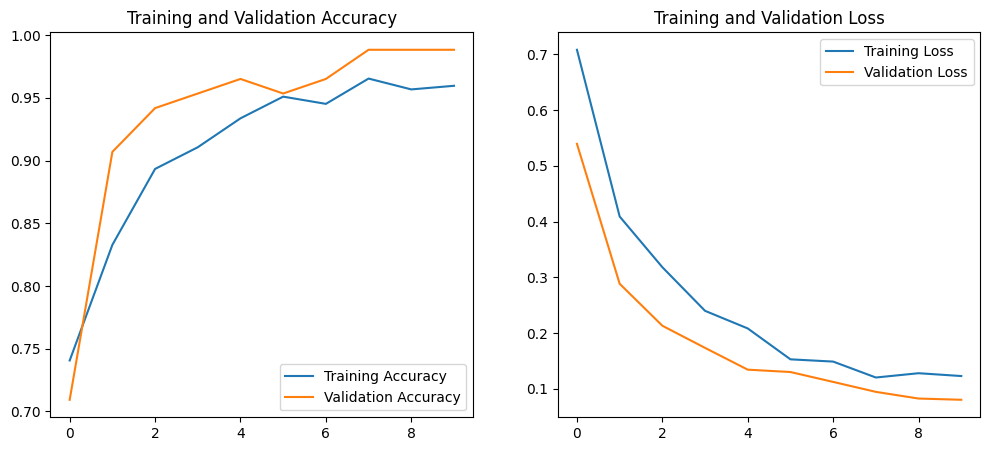

In [44]:
initial_acc = history.history['accuracy']
initial_val_acc = history.history['val_accuracy']
initial_loss = history.history['loss']
initial_val_loss = history.history['val_loss']

epochs_range = range(EPOCHS)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, initial_acc, label='Training Accuracy')
plt.plot(epochs_range, initial_val_acc, label='Validation Accuracy')
plt.legend()
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, initial_loss, label='Training Loss')
plt.plot(epochs_range, initial_val_loss, label='Validation Loss')
plt.legend()
plt.title('Training and Validation Loss')
plt.show()


In [45]:
val_loss, val_acc = model.evaluate(val_ds)
print(f'Validation accuracy: {val_acc*100:.2f}%')


3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 211ms/step - accuracy: 0.9884 - loss: 0.0804
Validation accuracy: 98.84%


In [46]:
%cd /content/drive/MyDrive/Week_7_Tut_Lab_Activities
model.save('macroinvertebrates_classifier.h5')


/content/drive/MyDrive/Week_7_Tut_Lab_Activities


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 329ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 291ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 211ms/step


<Figure size 1200x1200 with 0 Axes>

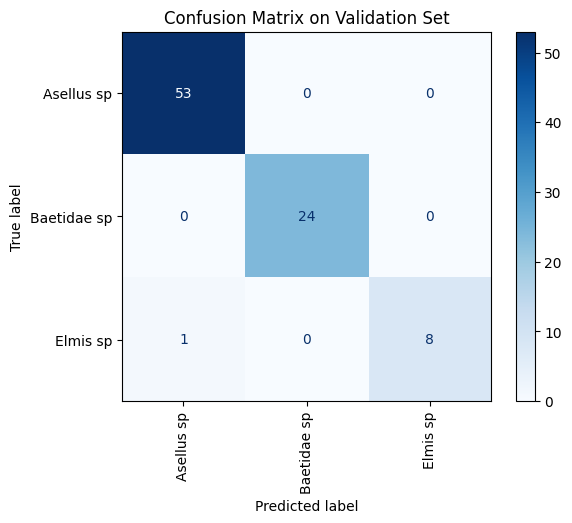

Weighted Precision: 0.9886
Weighted Recall: 0.9884
Weighted F1-score: 0.9881


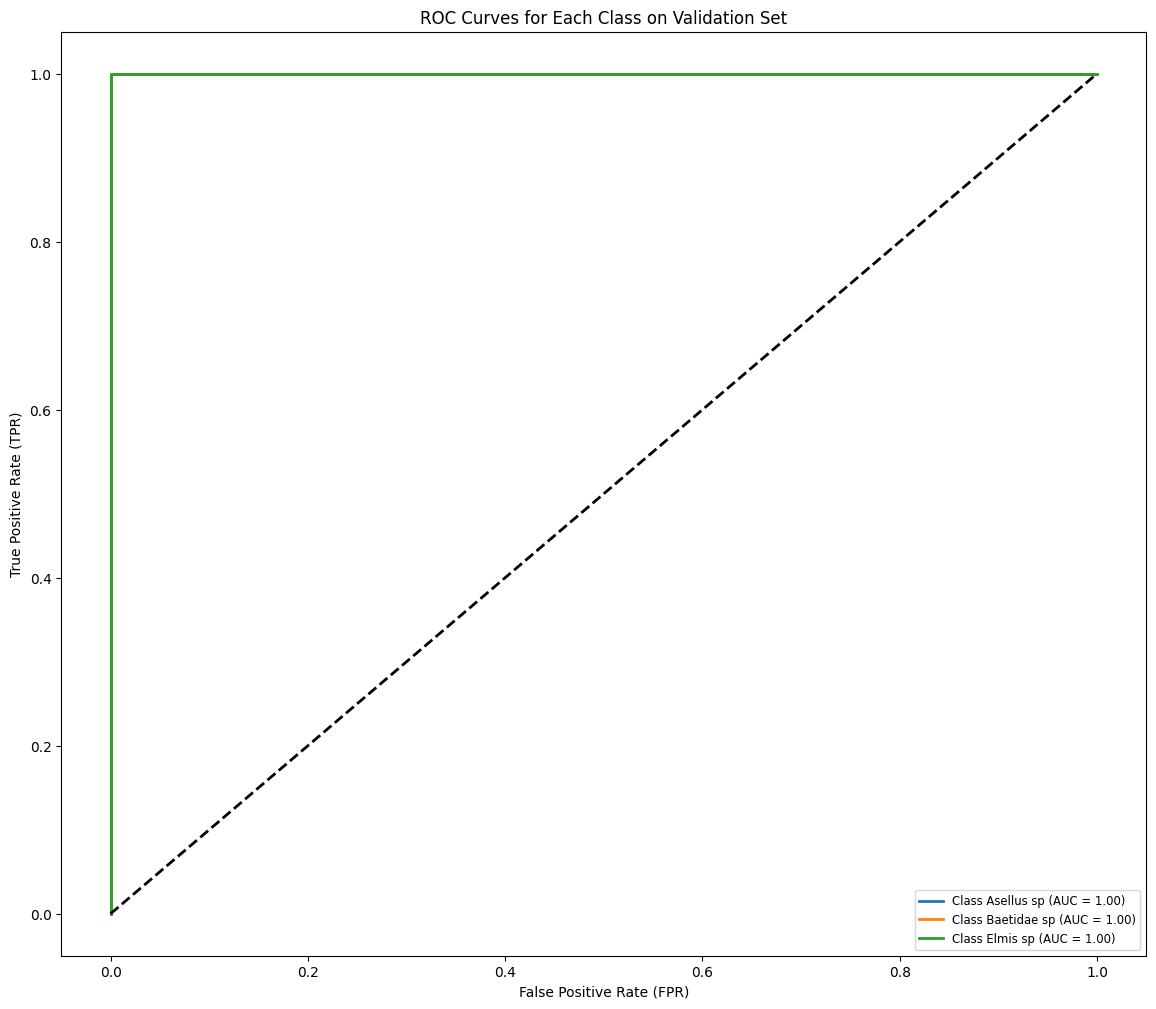

In [48]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    precision_recall_fscore_support,
    roc_curve, auc
)
from sklearn.preprocessing import label_binarize
import tensorflow as tf
import os

y_true = []
y_pred = []
y_scores = []

for images, labels in val_ds:
    preds = model.predict(images)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))
    y_scores.extend(preds)

y_true = np.array(y_true)
y_pred = np.array(y_pred)
y_scores = np.array(y_scores)

cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)

plt.figure(figsize=(12, 12))
disp.plot(cmap=plt.cm.Blues, xticks_rotation='vertical')
plt.title('Confusion Matrix on Validation Set')
plt.show()

precision, recall, f1, _ = precision_recall_fscore_support(
    y_true, y_pred, average='weighted'
)

print(f"Weighted Precision: {precision:.4f}")
print(f"Weighted Recall: {recall:.4f}")
print(f"Weighted F1-score: {f1:.4f}")
y_true_bin = label_binarize(y_true, classes=range(len(class_names)))
n_classes = y_true_bin.shape[1]

fpr = {}
tpr = {}
roc_auc = {}

plt.figure(figsize=(14, 12))

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], y_scores[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])
    plt.plot(
        fpr[i], tpr[i], lw=2,
        label=f'Class {class_names[i]} (AUC = {roc_auc[i]:0.2f})'
    )

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([-0.05, 1.05])
plt.ylim([-0.05, 1.05])
plt.xlabel("False Positive Rate (FPR)")
plt.ylabel("True Positive Rate (TPR)")
plt.title("ROC Curves for Each Class on Validation Set")
plt.legend(loc="lower right", fontsize='small')
plt.show()

Running inference on images from test folder...
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 595ms/step
Original Image: CPH-Asellus sp.-100-t.png --> Predicted: Elmis sp (94.75%)


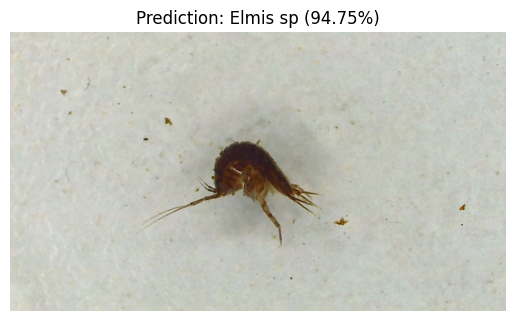

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
Original Image: CPH-Asellus sp.-15-v.png --> Predicted: Elmis sp (94.52%)


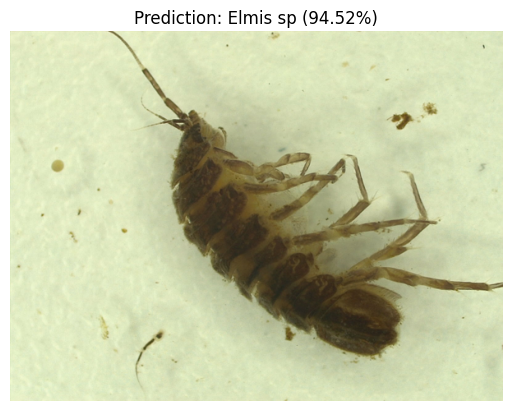

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
Original Image: CPH-Asellus sp.-12-t.png --> Predicted: Elmis sp (94.65%)


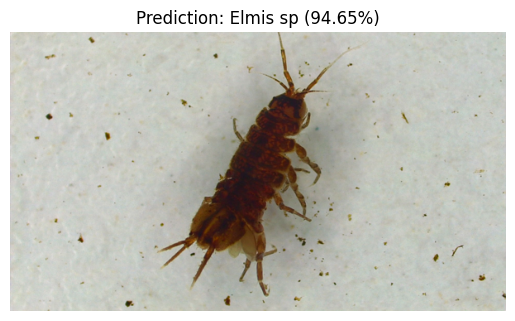

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
Original Image: CPH-Asellus sp.-16-t.png --> Predicted: Elmis sp (94.41%)


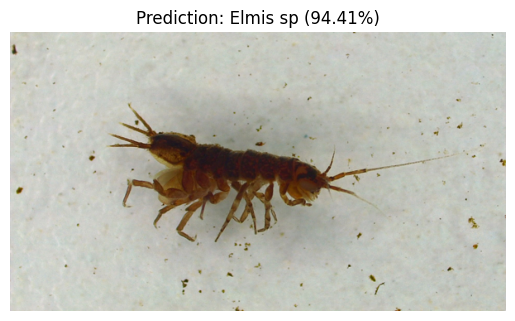

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
Original Image: CPH-Asellus sp.-22-t.png --> Predicted: Elmis sp (94.74%)


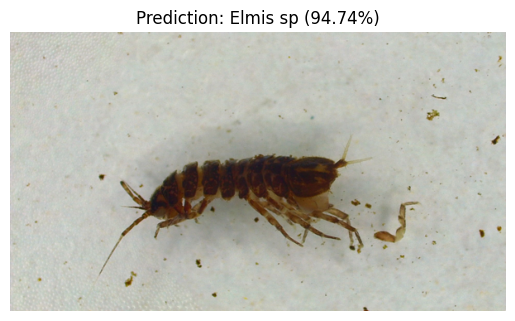

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
Original Image: CPH-Baetidae sp.-400-t.png --> Predicted: Elmis sp (94.67%)


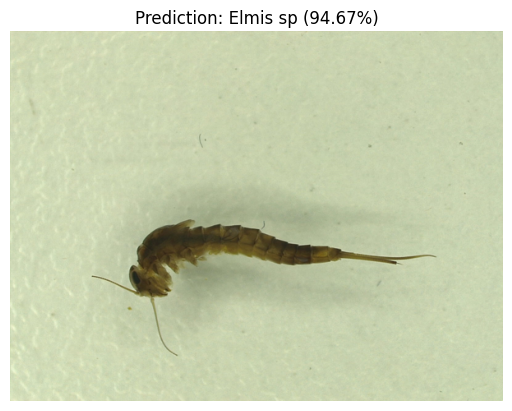

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
Original Image: CPH-Baetidae sp.-407-t.png --> Predicted: Elmis sp (94.74%)


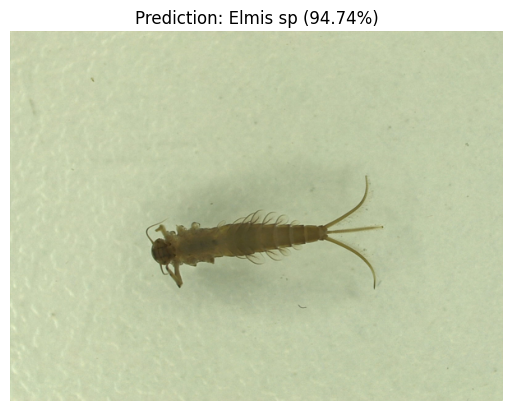

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
Original Image: CPH-Baetidae sp.-416-t.png --> Predicted: Elmis sp (94.86%)


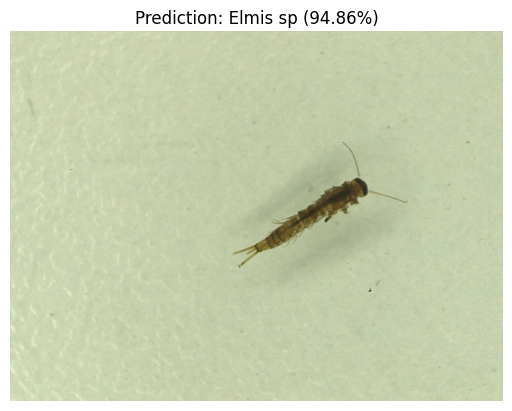

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
Original Image: CPH-Baetidae sp.-412-t.png --> Predicted: Elmis sp (94.64%)


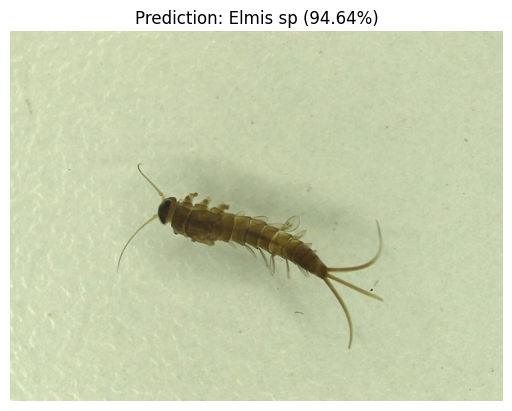

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
Original Image: CPH-Baetidae sp.-394-t.png --> Predicted: Elmis sp (94.64%)


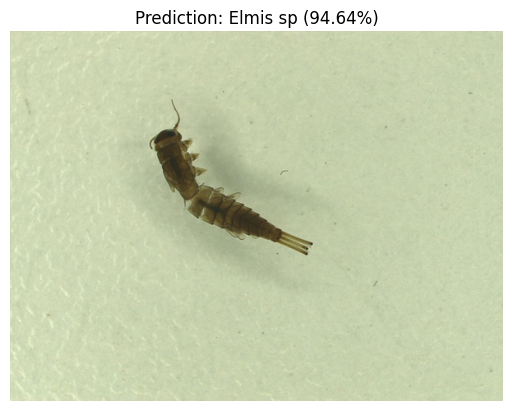

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
Original Image: CPH-Elmis sp.-524-t.png --> Predicted: Elmis sp (94.30%)


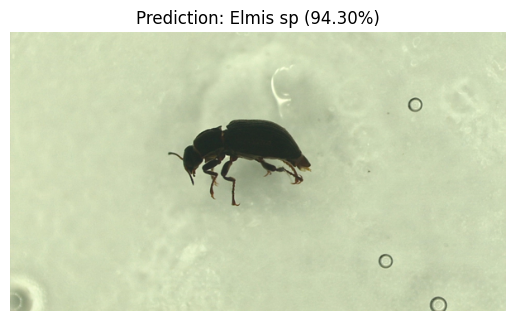

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
Original Image: CPH-Elmis sp.-503-t.png --> Predicted: Elmis sp (94.28%)


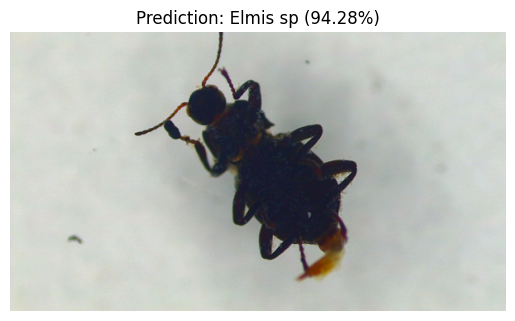

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
Original Image: CPH-Elmis sp.-515-t.png --> Predicted: Elmis sp (94.15%)


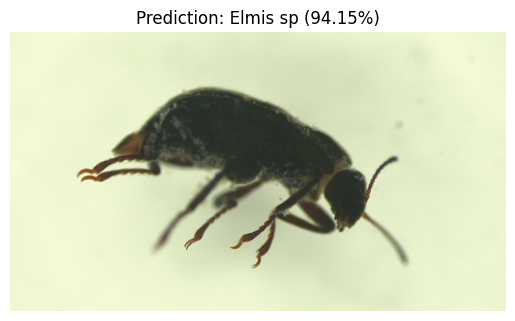

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
Original Image: CPH-Elmis sp.-520-t.png --> Predicted: Elmis sp (94.92%)


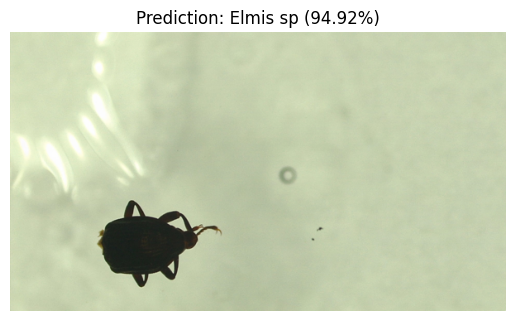

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
Original Image: CPH-Elmis sp.-510-t.png --> Predicted: Elmis sp (93.96%)


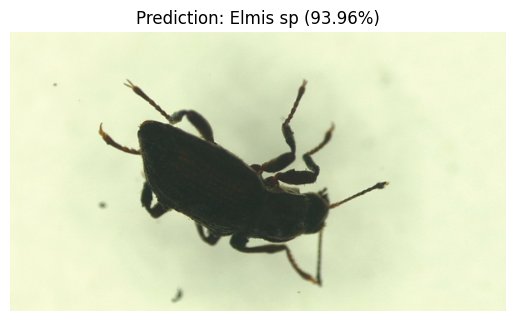

In [49]:
TEST_IMAGE_DIR = '/content/drive/MyDrive/Week_7_Tut_Lab_Activities/Assets/Insects_dataset/Test_data'
os.makedirs(TEST_IMAGE_DIR, exist_ok=True)

def load_and_preprocess_image(img_path, img_size=IMG_SIZE):
    img = image.load_img(img_path, target_size=img_size)
    img_array = image.img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)
    return img_array

def predict_new_images(test_dir):
    img_files = [f for f in os.listdir(test_dir) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]

    if not img_files:
        print(f"No images found in '{test_dir}'. Please add some images and rerun.")
        return

    for img_file in img_files:
        path = os.path.join(test_dir, img_file)
        img_arr = load_and_preprocess_image(path)
        preds = model.predict(img_arr)
        pred_idx = np.argmax(preds[0])
        confidence = preds[0][pred_idx]

        print(f"Original Image: {img_file} --> Predicted: {class_names[pred_idx]} ({confidence*100:.2f}%)")

        img = image.load_img(path)
        plt.imshow(img)
        plt.axis('off')
        plt.title(f"Prediction: {class_names[pred_idx]} ({confidence*100:.2f}%)")
        plt.show()

print("Running inference on images from test folder...")
predict_new_images(TEST_IMAGE_DIR)
